# LigandMPNN-FR Output Parser
Parses `stats/`, `seqs/`, and `relaxed/` directories from a pipeline run and visualizes per-cycle metrics.

In [10]:
# ── Configuration ─────────────────────────────────────────────
out_folder = "../test_output/lpmo_0_TK_48"  # path to --out_folder used in the run
# ──────────────────────────────────────────────────────────────

In [11]:
from glob import glob
import json, os
import numpy as np
import pandas as pd

# ── Load stats JSONs ────────────────────────────────────────────────────────
rows_all  = []   # every sequence across all cycles
rows_best = []   # best-selected structure per cycle

# Metrics inflated by CST energy terms → exclude from plots
_CST_INFLATED = {"ddg_after_relax_cst", "totalscore_after_cst_relax",
                 "res_totalscore_after_cst_relax"}

for json_path in sorted(glob(f"{out_folder}/stats/*.json")):
    with open(json_path) as f:
        data = json.load(f)

    cycle      = data.get("cycle")
    sel_metric = data.get("selection_metric", "")

    # best structure per cycle
    best_row = {
        "cycle":              cycle,
        "sequence":           data.get("best_sequence", ""),
        "mpnn":               data.get("best_mpnn_score"),
        "selection_metric":   sel_metric,
        "selection_value":    data.get("selection_value"),
        "num_sequences":      data.get("num_sequences_generated"),
        "sequence_diversity": data.get("sequence_diversity"),
    }
    best_metrics = {k: v for k, v in data.get("best_metrics", {}).items()
                    if k not in _CST_INFLATED}
    best_row.update(best_metrics)
    rows_best.append(best_row)

    # all sequences per cycle
    for entry in data.get("all_relax_scores", []):
        row = {
            "cycle":           cycle,
            "mpnn":            entry.get("mpnn"),
            "selection_value": entry.get("selection_value"),
        }
        row.update({k: v for k, v in entry.get("metrics", {}).items()
                    if k not in _CST_INFLATED})
        rows_all.append(row)

df_best = pd.DataFrame(rows_best).sort_values("cycle").reset_index(drop=True)
df_all  = pd.DataFrame(rows_all)

# Numeric metric columns (exclude metadata)
_META = {"cycle", "sequence", "selection_metric", "num_sequences", "sequence_diversity"}
metric_cols = [c for c in df_best.columns if c not in _META]

sel_metric_name = df_best["selection_metric"].iloc[0] if len(df_best) else "?"
print(f"Loaded {len(df_best)} cycles  |  {len(df_all)} total sequences")
print(f"Selection metric: {sel_metric_name}")
print(f"Available metrics: {[c for c in metric_cols if c not in ('selection_metric','selection_value')]}")
df_best[metric_cols].round(3)

Loaded 8 cycles  |  128 total sequences
Selection metric: rmsd_drift
Available metrics: ['mpnn', 'ddg_cst_relax_nocst_sf', 'ddg', 'fa_rep', 'totalscore', 'res_totalscore', 'rmsd_drift', 'ddg_drift', 'totalscore_drift']


,mpnn,selection_value,ddg_cst_relax_nocst_sf,ddg,fa_rep,totalscore,res_totalscore,rmsd_drift,ddg_drift,totalscore_drift
0,0.553,0.906,6.298,7.763,1992.506,1472.526,8.871,0.906,1.465,-13.977
1,0.565,0.292,4.624,3.482,2000.634,1439.663,8.673,0.292,-1.141,-6.158
2,0.525,0.523,3.916,4.172,2000.948,1433.952,8.638,0.523,0.256,-4.737
3,0.522,0.232,3.229,2.798,2002.900,1440.479,8.678,0.232,-0.431,-1.644
4,0.501,0.165,3.394,3.547,2000.154,1432.546,8.630,0.165,0.153,-2.229
5,0.523,0.386,3.306,2.990,2001.036,1434.018,8.639,0.386,-0.315,-1.733
6,0.493,0.177,3.337,2.857,1998.626,1432.404,8.629,0.177,-0.481,-1.108
7,0.502,0.258,5.057,3.962,2009.982,1446.131,8.712,0.258,-1.095,9.423


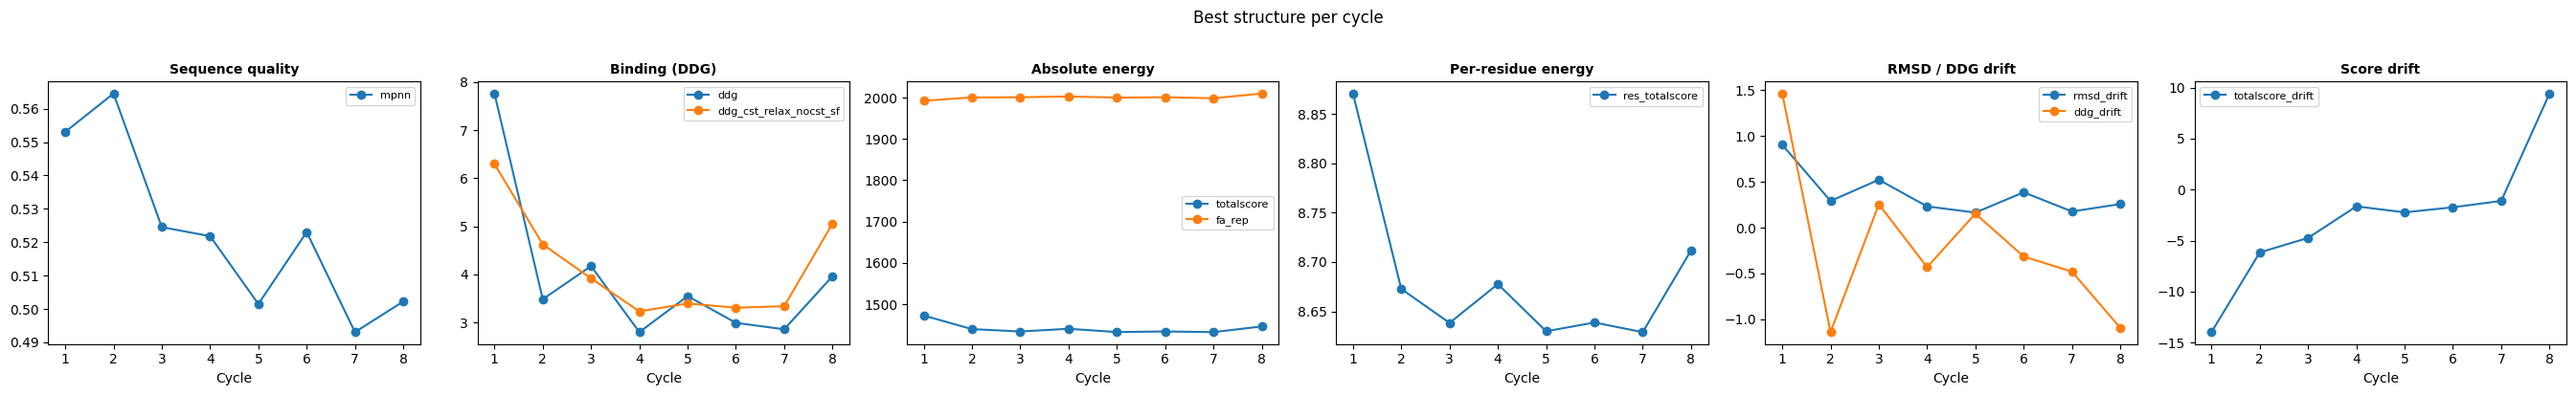

/tmp/ipykernel_831764/2573641062.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_cycle, labels=sorted(df_all["cycle"].unique()))
/tmp/ipykernel_831764/2573641062.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_cycle, labels=sorted(df_all["cycle"].unique()))
/tmp/ipykernel_831764/2573641062.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_cycle, labels=sorted(df_all["cycle"].unique()))
/tmp/ipykernel_831764/2573641062.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support

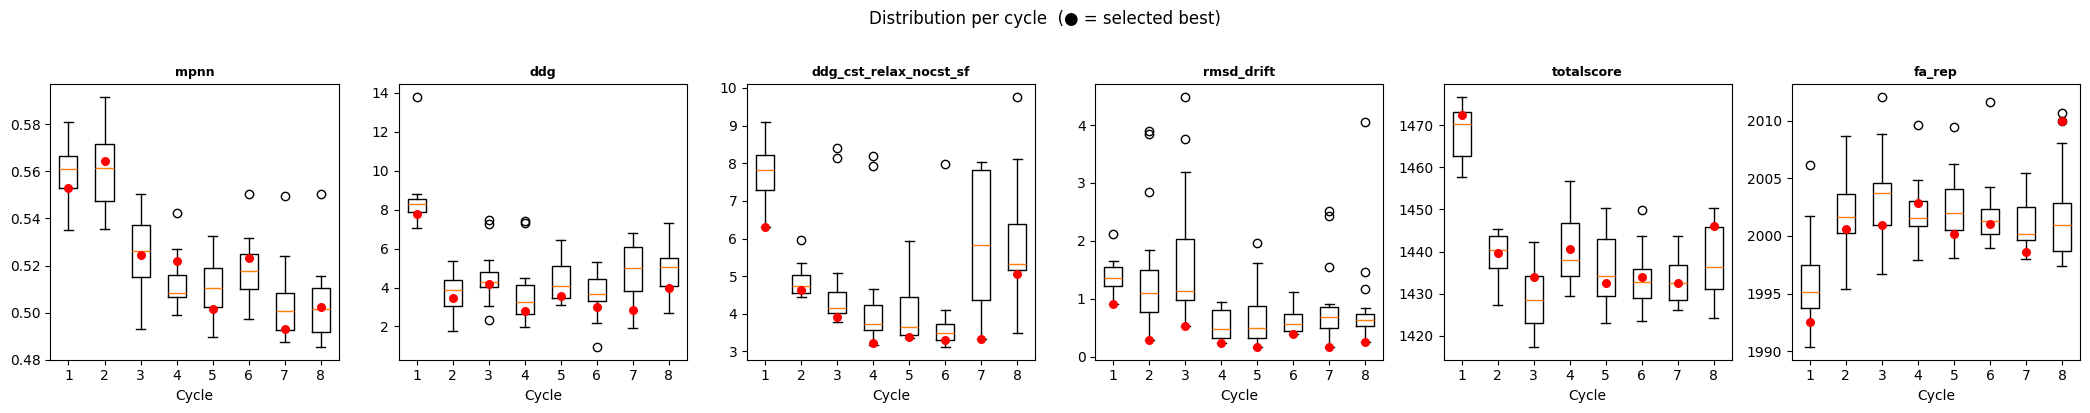

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

cycles = df_best["cycle"].values

# ── Metric groups ────────────────────────────────────────────────────────────
# 같은 그룹 내 지표는 동일 y축을 공유하므로 스케일이 유사한 것끼리만 묶음
# - res_totalscore (~8.8 REU/res) ↔ totalscore/fa_rep (~1400–2000 REU): 100배 차이 → 분리
# - totalscore_drift (~−14 to −6 REU)  ↔ rmsd_drift/ddg_drift (~0–1.5): 10배 차이 → 분리
GROUPS = {
    "Sequence quality":   ["mpnn"],
    "Binding (DDG)":      ["ddg", "ddg_cst_relax_nocst_sf"],
    "Absolute energy":    ["totalscore", "fa_rep"],
    "Per-residue energy": ["res_totalscore"],
    "RMSD / DDG drift":   ["rmsd_drift", "ddg_drift"],
    "Score drift":        ["totalscore_drift"],
}
# Only keep groups/metrics present in df_best
groups = {
    name: [m for m in mets if m in df_best.columns]
    for name, mets in GROUPS.items()
}
groups = {k: v for k, v in groups.items() if v}

# ── Figure 1: Best-per-cycle line plots ─────────────────────────────────────
n_groups = len(groups)
fig1, axes1 = plt.subplots(1, n_groups, figsize=(4.5 * n_groups, 4))
if n_groups == 1:
    axes1 = [axes1]

for ax, (group_name, metrics) in zip(axes1, groups.items()):
    for m in metrics:
        vals = pd.to_numeric(df_best[m], errors="coerce")
        ax.plot(cycles, vals, marker="o", label=m)
    ax.set_title(group_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Cycle")
    ax.legend(fontsize=8)
    ax.set_xticks(cycles)

fig1.suptitle("Best structure per cycle", y=1.02)
fig1.tight_layout()
fig1.savefig("best_per_cycle.svg", bbox_inches="tight")
plt.show()

# ── Figure 2: Per-cycle distribution (box plots) ────────────────────────────
box_metrics = [m for m in ["mpnn", "ddg", "ddg_cst_relax_nocst_sf",
                             "rmsd_drift", "totalscore", "fa_rep"]
               if m in df_all.columns]

n_box = len(box_metrics)
fig2, axes2 = plt.subplots(1, n_box, figsize=(3.5 * n_box, 4))
if n_box == 1:
    axes2 = [axes2]

for ax, m in zip(axes2, box_metrics):
    data_by_cycle = [
        pd.to_numeric(df_all[df_all["cycle"] == c][m], errors="coerce").dropna()
        for c in sorted(df_all["cycle"].unique())
    ]
    ax.boxplot(data_by_cycle, labels=sorted(df_all["cycle"].unique()))
    # Overlay best-per-cycle as red dot
    if m in df_best.columns:
        for i, c in enumerate(sorted(df_all["cycle"].unique()), 1):
            v = pd.to_numeric(df_best.loc[df_best["cycle"] == c, m], errors="coerce")
            if not v.empty and not v.isna().all():
                ax.scatter(i, v.values[0], color="red", zorder=5, s=30)
    ax.set_title(m, fontsize=9, fontweight="bold")
    ax.set_xlabel("Cycle")

fig2.suptitle("Distribution per cycle  (● = selected best)", y=1.02)
fig2.tight_layout()
fig2.savefig("distribution_per_cycle.svg", bbox_inches="tight")
plt.show()

In [13]:
# ── RMSD_drift 기준 사이클별 best 확인 ──────────────────────────────────────
from glob import glob
import json

# df_best에서 주요 컬럼만 추출 (rmsd_drift 오름차순 정렬)
show_cols = [c for c in ["cycle", "rmsd_drift", "ddg", "ddg_drift", "mpnn", "totalscore"] if c in df_best.columns]
df_rmsd_rank = df_best[show_cols].sort_values("rmsd_drift").reset_index(drop=True)
df_rmsd_rank.index += 1  # 순위 1부터

# 최적 사이클 (rmsd_drift 최소)
best = df_best.loc[df_best["rmsd_drift"].idxmin()]
best_cycle = int(best["cycle"])

# relaxed PDB 경로를 stats JSON에서 읽기
relaxed_pdb = "N/A"
matched = glob(f"{out_folder}/stats/*_cycle_{best_cycle}.json")
if matched:
    with open(matched[0]) as f:
        relaxed_pdb = json.load(f).get("relaxed_pdb", "N/A")

print(f"{'='*60}")
print(f"  RMSD_drift 기준 최적: Cycle {best_cycle}")
print(f"{'='*60}")
print(f"  rmsd_drift  : {best['rmsd_drift']:.4f} Å")
print(f"  ddg         : {best['ddg']:.4f} kcal/mol")
if "ddg_drift" in best:
    print(f"  ddg_drift   : {best['ddg_drift']:.4f}")
print(f"  mpnn        : {best['mpnn']:.4f}")
print(f"  relaxed_pdb : {relaxed_pdb}")
print(f"  sequence    : {best['sequence']}")
print()
print("사이클별 rmsd_drift 순위 (낮을수록 best):")
display(df_rmsd_rank.round(4))

  RMSD_drift 기준 최적: Cycle 5
  rmsd_drift  : 0.1651 Å
  ddg         : 3.5473 kcal/mol
  ddg_drift   : 0.1532
  mpnn        : 0.5015
  relaxed_pdb : /proj/home/ibs/aipd_lab/ltkmu4/ligandMPNN_FR/test_output/lpmo_0_TK_48/relaxed/0_TK_48_model_3_packed_11_1_cycle_5_relaxed.pdb
  sequence    : HTSAAAATALANAIAAVLPGARVHLVSAAGTDDIGVTNIANALTAAGLTVTVEYANRDPAKIKALITAAAADPGVDVVVVDPATYADQPELAEAVIEGLRAAAAADPSRLIIVATAHNDANGKKIADAAAELPNVVVLDTTAADFSEAAATAAIAAAVAAAR

사이클별 rmsd_drift 순위 (낮을수록 best):


,cycle,rmsd_drift,ddg,ddg_drift,mpnn,totalscore
1,5,0.1651,3.5473,0.1532,0.5015,1432.5463
2,7,0.1767,2.8568,-0.4805,0.4931,1432.4040
3,4,0.2320,2.7976,-0.4314,0.5218,1440.4792
4,8,0.2579,3.9618,-1.0949,0.5022,1446.1311
5,2,0.2917,3.4824,-1.1412,0.5646,1439.6630
6,6,0.3862,2.9902,-0.3153,0.5231,1434.0181
7,3,0.5233,4.1721,0.2558,0.5245,1433.9521
8,1,0.9056,7.7633,1.4653,0.5531,1472.5258
